# k-Fold Cross-Validation: Polynomial Model Selection

We perform **5-fold cross-validation** with consecutive folds of size 2 on a small dataset, comparing four polynomial model classes: constant (H₀), linear (H₁), quadratic (H₂), and cubic (H₃).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Dataset
x = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5])
y = np.array([ 4.2,  2.4, 1.0,  0.5, 0.2, 0.6, 1.1, 2.1, 4.3, 6.0])

n = len(x)
k = 5          # number of folds
fold_size = 2  # consecutive folds of size 2

degrees = [0, 1, 2, 3]
model_names = ['H₀ (Constant)', 'H₁ (Linear)', 'H₂ (Quadratic)', 'H₃ (Cubic)']

print(f"Dataset size: {n} points")
print(f"Folds: {k} × {fold_size} = {k*fold_size} points")
print()
print(f"{'x':>6}  {'y':>5}")
for xi, yi in zip(x, y):
    print(f"{xi:>6.1f}  {yi:>5.1f}")

Dataset size: 10 points
Folds: 5 × 2 = 10 points

     x      y
  -2.0    4.2
  -1.5    2.4
  -1.0    1.0
  -0.5    0.5
   0.0    0.2
   0.5    0.6
   1.0    1.1
   1.5    2.1
   2.0    4.3
   2.5    6.0


## Part (a): 5-Fold Cross-Validation MSE

Folds are consecutive pairs:
- Fold 1: indices 0–1 &nbsp; → x ∈ {−2, −1.5}
- Fold 2: indices 2–3 &nbsp; → x ∈ {−1, −0.5}
- Fold 3: indices 4–5 &nbsp; → x ∈ {0, 0.5}
- Fold 4: indices 6–7 &nbsp; → x ∈ {1, 1.5}
- Fold 5: indices 8–9 &nbsp; → x ∈ {2, 2.5}

In [2]:
def fit_poly(x_train, y_train, degree):
    """Fit polynomial of given degree; degree 0 returns mean."""
    coeffs = np.polyfit(x_train, y_train, degree)
    return coeffs

def predict_poly(x_val, coeffs):
    return np.polyval(coeffs, x_val)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# Build folds: list of validation index arrays
folds = [np.arange(i, i + fold_size) for i in range(0, n, fold_size)]

print("Fold definitions:")
for i, f in enumerate(folds):
    print(f"  Fold {i+1}: indices {f.tolist()}  →  x = {x[f].tolist()}")

print()
print("-" * 65)
print(f"{'Fold':<6}" + "".join(f"{'Degree '+str(d):>14}" for d in degrees))
print("-" * 65)

fold_mses = {d: [] for d in degrees}

for fold_idx, val_idx in enumerate(folds):
    train_idx = np.concatenate([folds[j] for j in range(k) if j != fold_idx])
    x_train, y_train = x[train_idx], y[train_idx]
    x_val,   y_val   = x[val_idx],   y[val_idx]

    row = f"{fold_idx+1:<6}"
    for d in degrees:
        coeffs  = fit_poly(x_train, y_train, d)
        y_pred  = predict_poly(x_val, coeffs)
        err     = mse(y_val, y_pred)
        fold_mses[d].append(err)
        row += f"{err:>14.4f}"
    print(row)

print("-" * 65)
avg_row = f"{'Avg MSE':<6}"
avg_mses = {}
for d in degrees:
    avg = np.mean(fold_mses[d])
    avg_mses[d] = avg
    avg_row += f"{avg:>14.4f}"
print(avg_row)
print("-" * 65)

Fold definitions:
  Fold 1: indices [0, 1]  →  x = [-2.0, -1.5]
  Fold 2: indices [2, 3]  →  x = [-1.0, -0.5]
  Fold 3: indices [4, 5]  →  x = [0.0, 0.5]
  Fold 4: indices [6, 7]  →  x = [1.0, 1.5]
  Fold 5: indices [8, 9]  →  x = [2.0, 2.5]

-----------------------------------------------------------------
Fold        Degree 0      Degree 1      Degree 2      Degree 3
-----------------------------------------------------------------
1             2.5656       25.6751        0.1268        0.3909
2             3.5314        2.2595        0.0285        0.0194
3             5.3300        5.2977        0.0305        0.0280
4             0.8900        2.4943        0.0488        0.2238
5            13.9539       25.8575        0.1302        1.5928
-----------------------------------------------------------------
Avg MSE        5.2542       12.3168        0.0730        0.4510
-----------------------------------------------------------------


## Part (b): Model Selection & Full-Dataset Fit

In [3]:
best_degree = min(avg_mses, key=avg_mses.get)
print("Average validation MSE by model:")
for d in degrees:
    marker = "  ← SELECTED" if d == best_degree else ""
    print(f"  {model_names[d]:<20}  MSE = {avg_mses[d]:.4f}{marker}")

print()
print(f"Selected model: {model_names[best_degree]}  (degree {best_degree})")
print()

# Fit selected model on full dataset
best_coeffs = fit_poly(x, y, best_degree)
print(f"Full-dataset fit — polynomial coefficients (highest degree first):")
for i, c in enumerate(best_coeffs):
    power = best_degree - i
    print(f"  x^{power} coefficient: {c:.6f}")

# Pretty-print the polynomial
terms = []
for i, c in enumerate(best_coeffs):
    power = best_degree - i
    if power == 0:
        terms.append(f"{c:+.4f}")
    elif power == 1:
        terms.append(f"{c:+.4f}x")
    else:
        terms.append(f"{c:+.4f}x^{power}")
print()
print("  ĥ(x) = " + " ".join(terms))

Average validation MSE by model:
  H₀ (Constant)         MSE = 5.2542
  H₁ (Linear)           MSE = 12.3168
  H₂ (Quadratic)        MSE = 0.0730  ← SELECTED
  H₃ (Cubic)            MSE = 0.4510

Selected model: H₂ (Quadratic)  (degree 2)

Full-dataset fit — polynomial coefficients (highest degree first):
  x^2 coefficient: 0.962121
  x^1 coefficient: -0.030152
  x^0 coefficient: 0.203030

  ĥ(x) = +0.9621x^2 -0.0302x +0.2030


## Part (c): Plot — Raw Data + All Four Fitted Curves

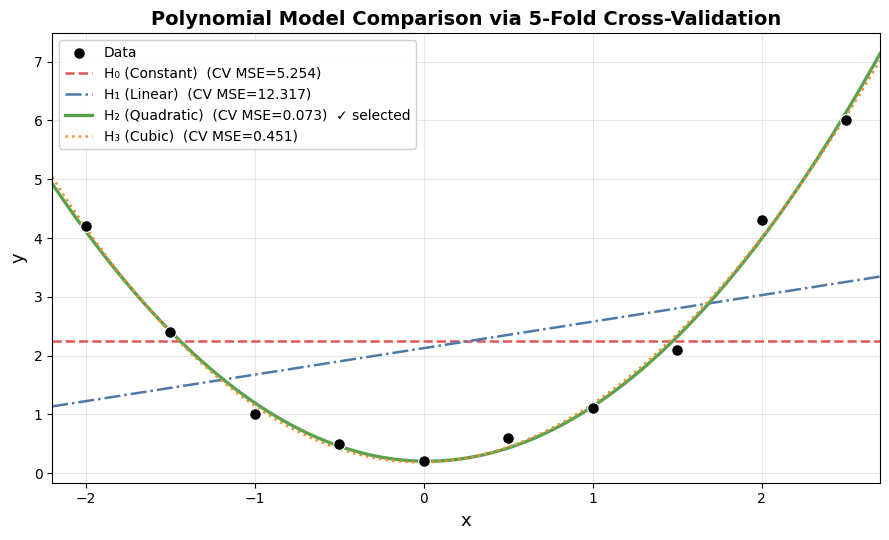

Plot saved.


In [5]:
x_plot = np.linspace(x.min() - 0.2, x.max() + 0.2, 400)

colors    = ['#e15759', '#4e79a7', '#59a14f', '#f28e2b']
linesty   = ['--', '-.', '-', ':']
linewidths = [1.8, 1.8, 2.4, 1.8]

fig, ax = plt.subplots(figsize=(9, 5.5))

# Raw data
ax.scatter(x, y, color='black', zorder=5, s=70, label='Data', edgecolors='white', linewidths=0.8)

# Fitted curves (full dataset)
for d, name, col, ls, lw in zip(degrees, model_names, colors, linesty, linewidths):
    coeffs  = fit_poly(x, y, d)
    y_plot  = predict_poly(x_plot, coeffs)
    avg_err = avg_mses[d]
    label   = f"{name}  (CV MSE={avg_err:.3f})"
    if d == best_degree:
        label += "  ✓ selected"
    ax.plot(x_plot, y_plot, color=col, linestyle=ls, linewidth=lw, label=label)

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Polynomial Model Comparison via 5-Fold Cross-Validation', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.92)
ax.grid(True, alpha=0.3)
ax.set_xlim(x_plot[0], x_plot[-1])

plt.tight_layout()
plt.savefig('kfold_cv_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")